# Original Time Series Visualization



## Objective:
The objective of this analysis is to visualize the daily units sold over time using the cleaned retail store inventory dataset. This visualization provides an initial understanding of demand behavior and serves as the foundation for subsequent time-series decomposition, anomaly detection, and demand forecasting.

## Import required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Load the cleaned dataset


In [2]:
df = pd.read_excel("clean_retail_storeinventory.xlsx")
df.head()


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


##description about the dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Category            73100 non-null  object        
 4   Region              73100 non-null  object        
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  object        
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64   

## Preparing Daily Sales Time Series

In [4]:

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")
daily_sales = df.groupby("Date")["Units Sold"].sum()
daily_sales.head()

,Units Sold
Date,
2022-01-01,14484
2022-01-02,13415
2022-01-03,13681
2022-01-04,14084
2022-01-05,12572


## Plot the original time series

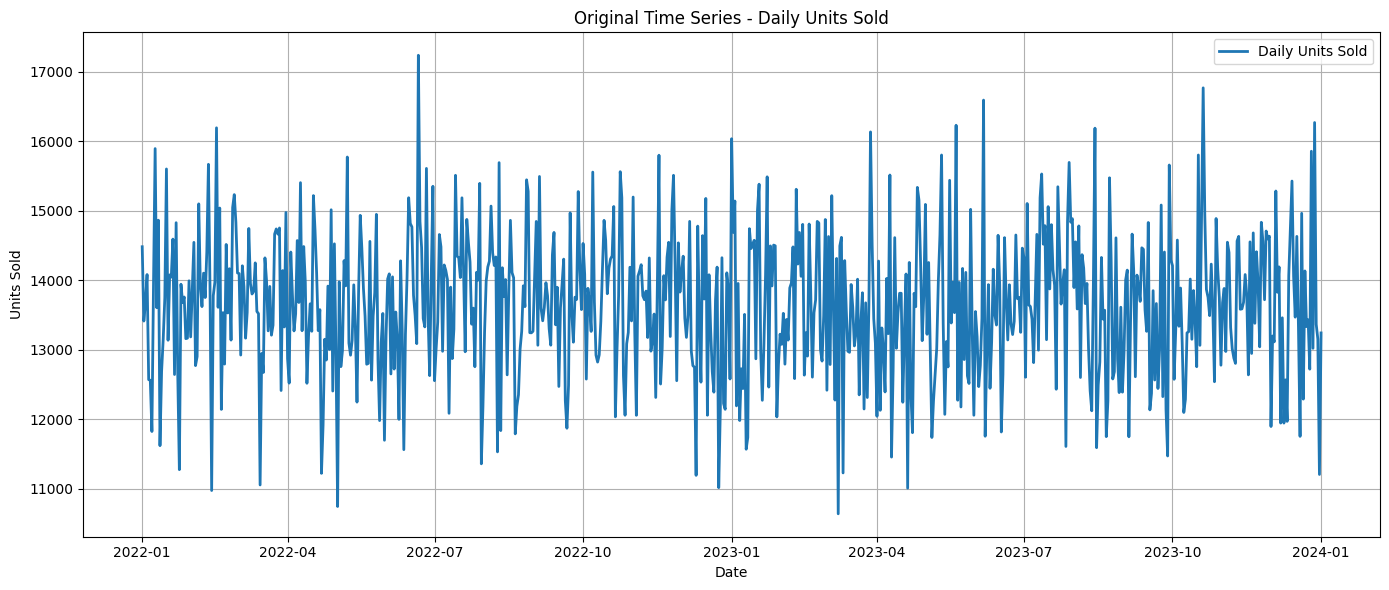

In [5]:
plt.figure(figsize=(14,6))
plt.plot(
    daily_sales.index,
    daily_sales.values,
    linewidth=2,
    label="Daily Units Sold"
)
plt.title("Original Time Series - Daily Units Sold")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Observation

- The visualization represents daily sales over the available time period.
- Demand varies across different dates, indicating fluctuations in customer purchasing behavior.
- This graph serves as the baseline for identifying trends, seasonality, and anomalies in the upcoming analyses.

# Weekly and Monthly Trend Analysis



## Objective

The objective of this analysis is to examine sales patterns at different time intervals by aggregating the daily units sold into weekly and monthly totals. This helps identify broader demand trends and supports inventory planning and demand forecasting.

# Create weekly and monthly sales aggregates

In [6]:
weekly_sales = daily_sales.resample("W").sum()
weekly_sales = weekly_sales.iloc[:-1]

monthly_sales = daily_sales.resample("M").sum()
monthly_sales = monthly_sales.iloc[:-1]

/tmp/ipykernel_857/1151718321.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = daily_sales.resample("M").sum()


## Weekly Units Sold Trend

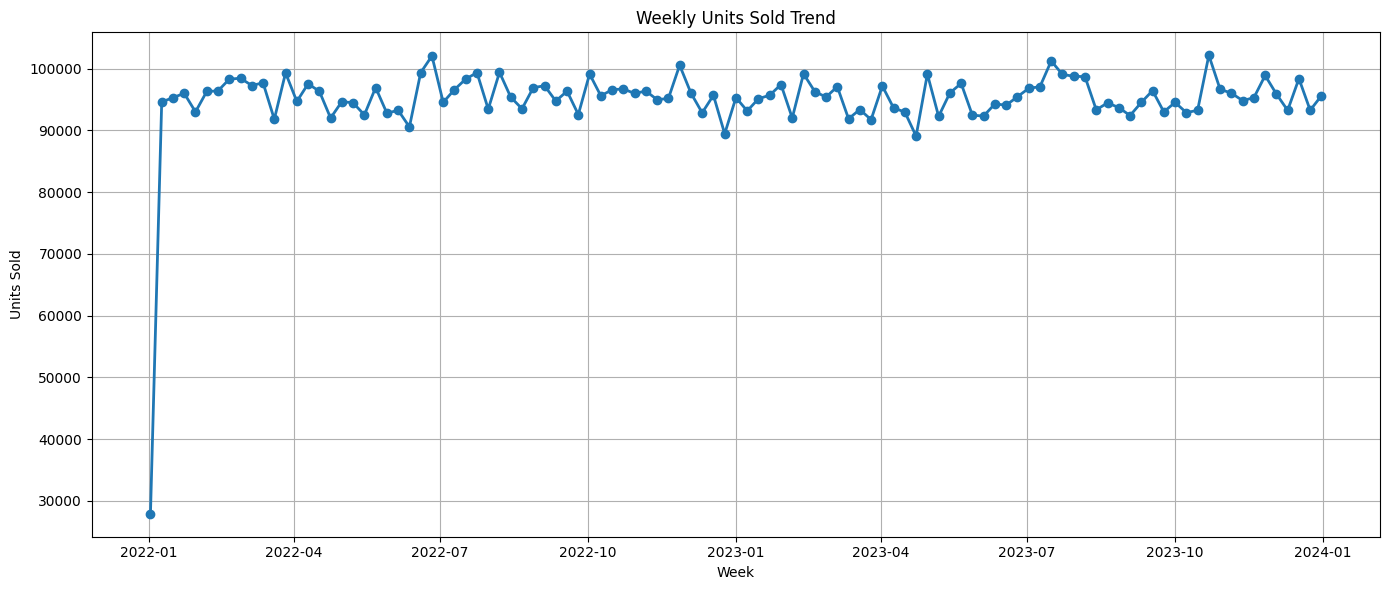

In [7]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales.index,
    weekly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Weekly Units Sold Trend")
plt.xlabel("Week")
plt.ylabel("Units Sold")
plt.grid(True)

plt.tight_layout()
plt.show()

## Monthly Units Sold Trend

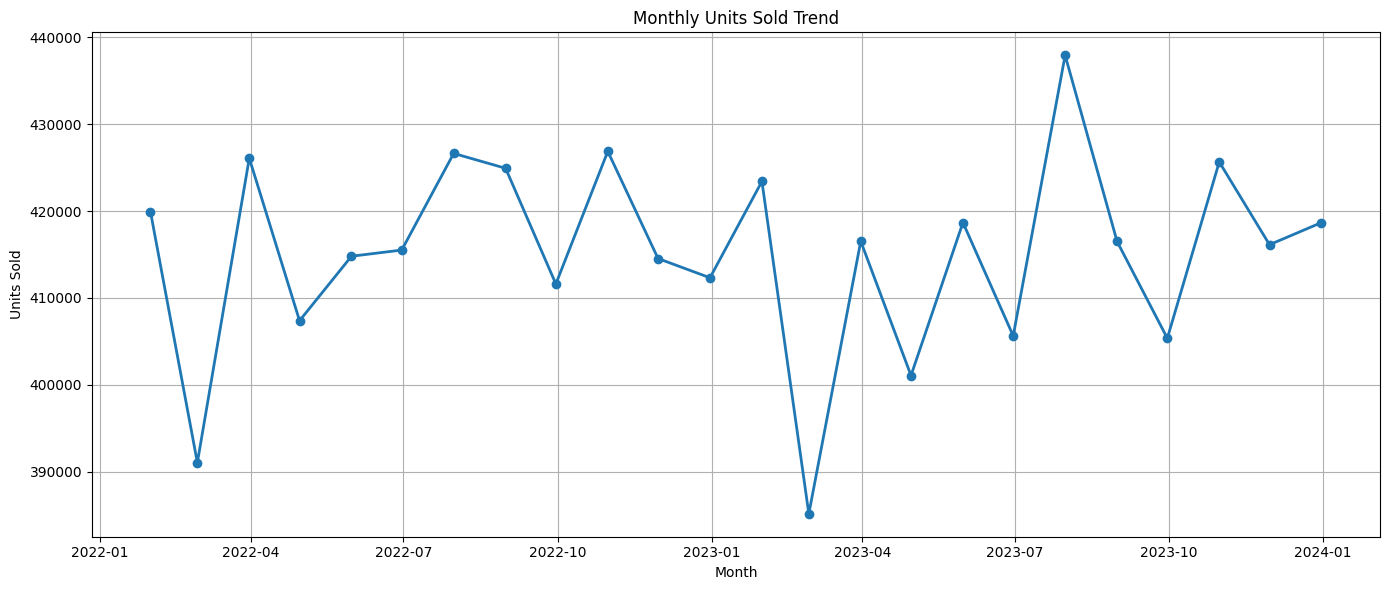

In [8]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Units Sold Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.grid(True)

plt.tight_layout()
plt.show()

## Weekly vs Monthly Trend Comparison

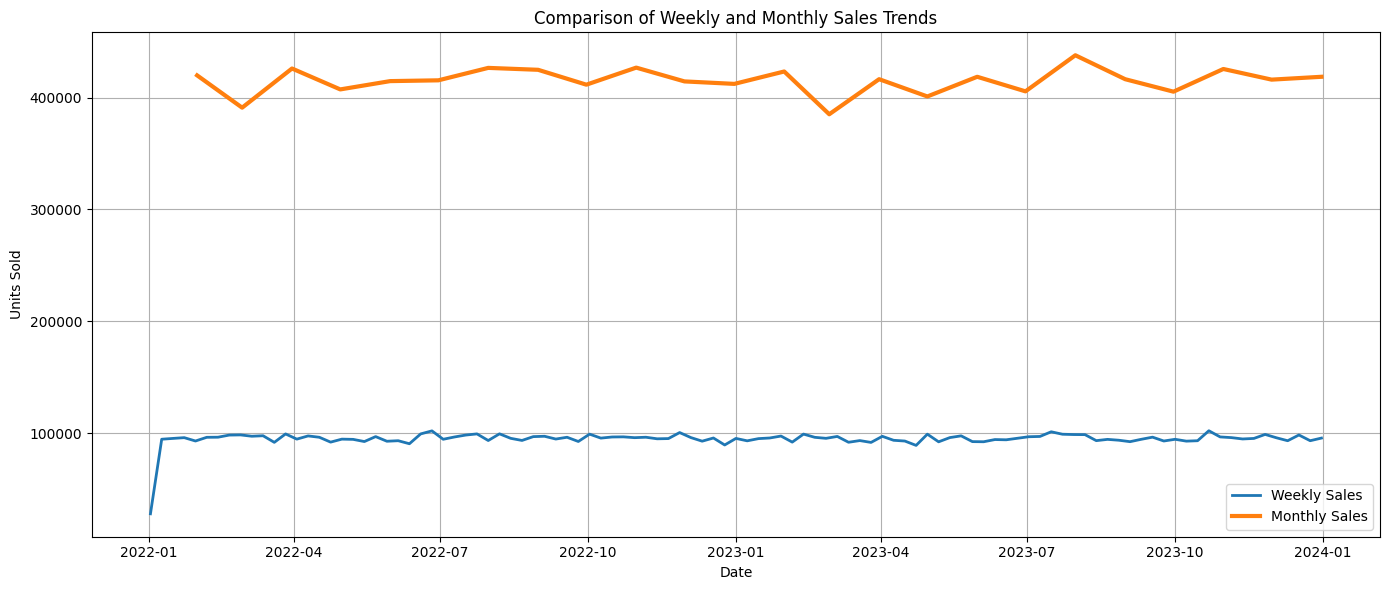

In [9]:
plt.figure(figsize=(14,6))

plt.plot(weekly_sales.index, weekly_sales.values,
         label='Weekly Sales',
         linewidth=2)

plt.plot(monthly_sales.index, monthly_sales.values,
         label='Monthly Sales',
         linewidth=3)

plt.title("Comparison of Weekly and Monthly Sales Trends")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

##Display Summary Statistics

In [10]:
print("Weekly Sales Summary")
display(weekly_sales.describe())

print("Monthly Sales Summary")
display(monthly_sales.describe())

Weekly Sales Summary


,Units Sold
count,105.000000
mean,94879.409524
std,7090.368292
min,27899.000000
25%,93310.000000
50%,95434.000000
75%,97072.000000
max,102154.000000


Monthly Sales Summary


,Units Sold
count,24.000000
mean,415097.416667
std,11755.137903
min,385168.000000
25%,410552.500000
50%,416313.500000
75%,423785.000000
max,437919.000000


## Observation

- The weekly trend captures short-term demand fluctuations with more frequent variations.
- The monthly trend provides a smoother representation of overall sales performance.
- Comparing both trends helps identify demand behavior at different time scales.
- Weekly analysis supports operational planning, while monthly analysis aids strategic inventory management and forecasting.

# Time-Series Decomposition



## Objective

Time-series decomposition separates a time series into three fundamental components:

- **Trend:** Represents the long-term direction of the data.
- **Seasonal:** Captures recurring patterns that repeat over regular intervals.
- **Residual:** Represents random fluctuations that cannot be explained by the trend or seasonality.

This analysis helps understand the underlying structure of demand before applying anomaly detection and forecasting techniques.

## Import required library

In [11]:
from statsmodels.tsa.seasonal import seasonal_decompose

## Perform additive decomposition

In [12]:
decomposition = seasonal_decompose(
    daily_sales,
    model="additive",
    period=30
)

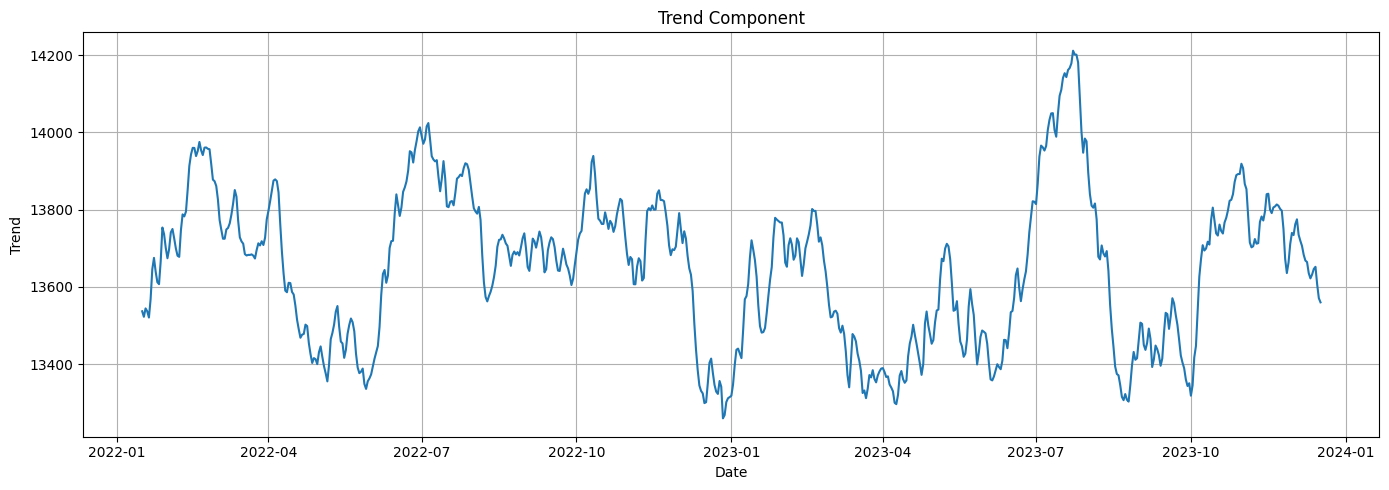

In [13]:
plt.figure(figsize=(14,5))

plt.plot(decomposition.trend)

plt.title("Trend Component")
plt.xlabel("Date")
plt.ylabel("Trend")
plt.grid(True)

plt.tight_layout()
plt.show()

## Seasonal Component

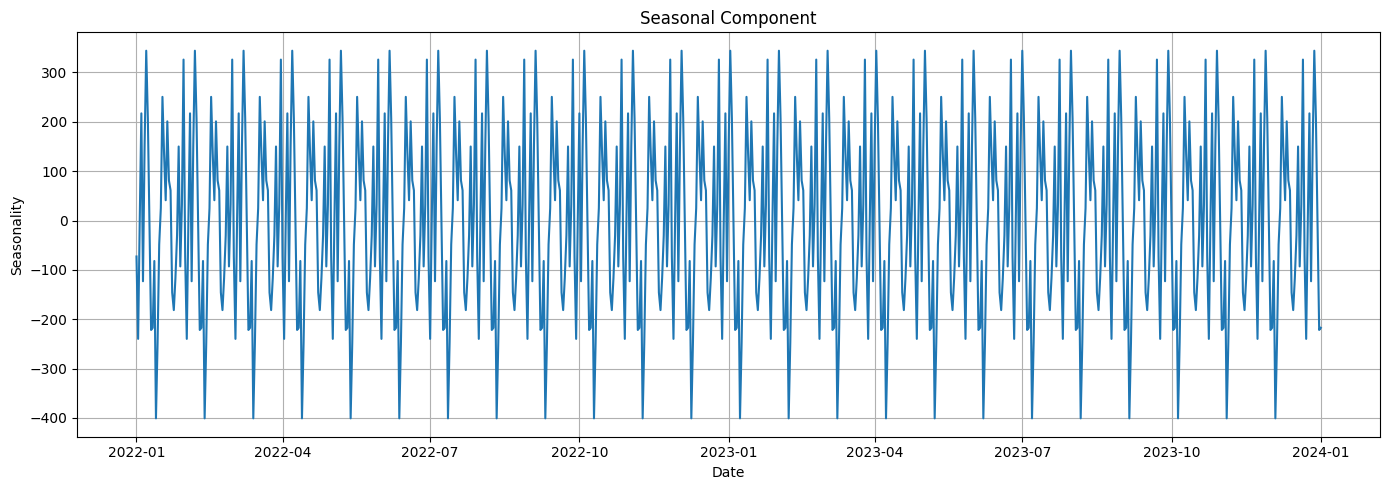

In [14]:
plt.figure(figsize=(14,5))

plt.plot(decomposition.seasonal)

plt.title("Seasonal Component")
plt.xlabel("Date")
plt.ylabel("Seasonality")
plt.grid(True)

plt.tight_layout()
plt.show()

## Residual Component

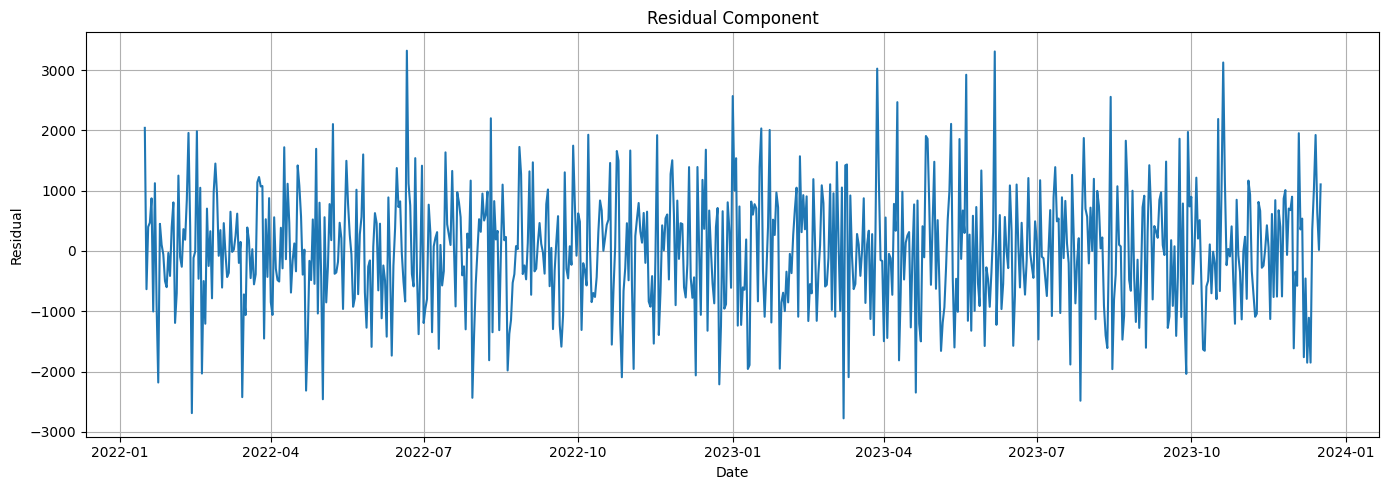

In [15]:
plt.figure(figsize=(14,5))

plt.plot(decomposition.resid)

plt.title("Residual Component")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True)

plt.tight_layout()
plt.show()

## Observation

### Trend
The trend component represents the long-term movement in sales. It helps identify whether demand is generally increasing, decreasing, or remaining stable over time.

### Seasonal
The seasonal component captures recurring patterns that repeat at regular intervals, indicating predictable variations in customer demand.

### Residual
The residual component represents irregular fluctuations that are not explained by the trend or seasonal patterns. These may arise from unexpected events or random variations.